In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Define path to the pre-processed SMARD dataset
file_path = (
    "/content/drive/MyDrive/Colab Notebooks/SMARD_Cleaned_20260806_20260816.csv"
)

# Verify file existence
if os.path.exists(file_path):
  print("Dataset found successfully! Proceeding with data loading...")
else:
  print(
      "File not found! Please verify the folder structure in your Google Drive."
  )

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset found successfully! Proceeding with data loading...


 CORPORATE PPA STRUCTURING, CANNIBALIZATION & BANKABILITY ENGINE
Contract Structure  Annual Revenue [k€]  Daily 95% VaR [€]  Daily 95% CVaR [€]  Capture Price [€/MWh]
 Merchant Baseline               4698.6             2022.0               842.0                  74.36
   Pay-as-Produced               3917.9             1328.0               685.0                  62.00
 Pay-as-Forecasted               3811.6             1271.0               656.0                  60.32
   Baseload Collar               4610.9             1061.0               150.0                  72.97


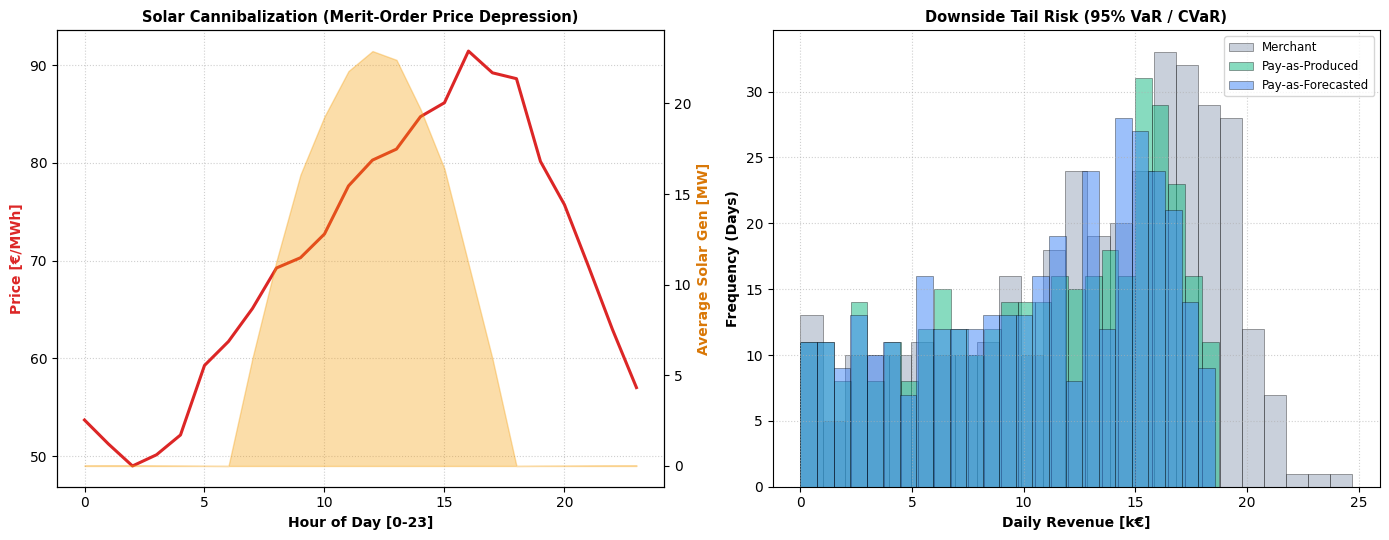


File 'corporate_ppa_valuation_results.csv' saved successfully.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================================
# 1. 8,760h SOLAR GENERATION & CORRELATED SPOT PRICE GENERATOR
# ==========================================================
np.random.seed(42)
HOURS = 8760
h_arr = np.arange(HOURS)
doy = (h_arr // 24) % 365
hod = h_arr % 24

# Solar profile with seasonal & diurnal shape
solar_elevation = np.sin(np.pi * (hod - 6) / 12) * np.sin(np.pi * (doy + 10) / 365)
solar_elevation = np.clip(solar_elevation, 0.0, 1.0)
pv_capacity_mw = 50.0
# Add weather volatility (cloud cover intermittency)
weather_noise = np.random.beta(5, 2, HOURS)
solar_gen_mwh = pv_capacity_mw * solar_elevation * weather_noise

# Merit-Order Effect & Cannibalization: Spot prices plunge during peak solar production
base_market_price = 75.0 + 25.0 * np.sin(2 * np.pi * (hod - 8) / 24)
cannibalization_drag = -45.0 * (solar_gen_mwh / pv_capacity_mw) ** 1.3
gas_volatility = np.random.normal(0, 20.0, HOURS)
spot_price_eur = np.clip(base_market_price + cannibalization_drag + gas_volatility, -15.0, 240.0)

# Forecasted Generation (with day-ahead weather forecast error)
forecast_error = np.random.normal(0, 0.12, HOURS)
solar_forecast_mwh = np.clip(solar_gen_mwh * (1.0 + forecast_error), 0.0, pv_capacity_mw)

df_market = pd.DataFrame({
    "hour": h_arr,
    "hod": hod,
    "solar_gen_mwh": solar_gen_mwh,
    "solar_forecast_mwh": solar_forecast_mwh,
    "spot_price_eur": spot_price_eur
})

# ==========================================================
# 2. PPA CONTRACT STRUCTURING & VALUATION ENGINES
# ==========================================================
PPA_STRIKE_EUR = 62.0      # Negotiated Fixed Strike Price
COLLAR_FLOOR_EUR = 50.0    # Baseload Collar Floor
COLLAR_CAP_EUR = 85.0      # Baseload Collar Cap
IMBALANCE_PENALTY_PCT = 0.25 # 25% penalty on imbalance delta

# Strategy 1: Merchant Exposure (No PPA)
df_market["rev_merchant"] = df_market["solar_gen_mwh"] * df_market["spot_price_eur"]

# Strategy 2: Pay-as-Produced (Offtaker absorbs volumetric & shape risk)
df_market["rev_pay_as_produced"] = df_market["solar_gen_mwh"] * PPA_STRIKE_EUR

# Strategy 3: Pay-as-Forecasted (Generator absorbs day-ahead imbalance penalties)
imbalance_vol = df_market["solar_gen_mwh"] - df_market["solar_forecast_mwh"]
imbalance_cashflow = np.where(
    imbalance_vol >= 0,
    imbalance_vol * df_market["spot_price_eur"] * (1.0 - IMBALANCE_PENALTY_PCT),
    imbalance_vol * df_market["spot_price_eur"] * (1.0 + IMBALANCE_PENALTY_PCT)
)
df_market["rev_pay_as_forecasted"] = (df_market["solar_forecast_mwh"] * PPA_STRIKE_EUR) + imbalance_cashflow

# Strategy 4: Baseload Equivalent with Synthetic Collar Option
mean_annual_hourly_gen = df_market["solar_gen_mwh"].mean()
collar_price = np.clip(df_market["spot_price_eur"], COLLAR_FLOOR_EUR, COLLAR_CAP_EUR)
# Generator must deliver flat volume, buying/selling difference on spot
shape_mismatch_vol = df_market["solar_gen_mwh"] - mean_annual_hourly_gen
df_market["rev_baseload_collar"] = (mean_annual_hourly_gen * collar_price) + (shape_mismatch_vol * df_market["spot_price_eur"])

# ==========================================================
# 3. BANKABILITY METRICS: MONTE CARLO & VaR / CVaR (95%)
# ==========================================================
# Aggregate daily cashflows to compute distribution metrics
df_daily = df_market.groupby(df_market["hour"] // 24).agg({
    "rev_merchant": "sum",
    "rev_pay_as_produced": "sum",
    "rev_pay_as_forecasted": "sum",
    "rev_baseload_collar": "sum"
})

def calculate_risk_metrics(series: pd.Series):
    var_95 = float(np.percentile(series, 5)) # 5th percentile worst daily cashflow
    cvar_95 = float(series[series <= var_95].mean())
    annual_rev = float(series.sum())
    return annual_rev, var_95, cvar_95

contracts = ["Merchant Baseline", "Pay-as-Produced", "Pay-as-Forecasted", "Baseload Collar"]
cols = ["rev_merchant", "rev_pay_as_produced", "rev_pay_as_forecasted", "rev_baseload_collar"]

results_summary = []
for name, col in zip(contracts, cols):
    ann_rev, var95, cvar95 = calculate_risk_metrics(df_daily[col])
    results_summary.append({
        "Contract Structure": name,
        "Annual Revenue [k€]": round(ann_rev / 1000.0, 1),
        "Daily 95% VaR [€]": round(var95, 0),
        "Daily 95% CVaR [€]": round(cvar95, 0),
        "Capture Price [€/MWh]": round(ann_rev / df_market["solar_gen_mwh"].sum(), 2)
    })

df_results = pd.DataFrame(results_summary)
print("=" * 85)
print(" CORPORATE PPA STRUCTURING, CANNIBALIZATION & BANKABILITY ENGINE")
print("=" * 85)
print(df_results.to_string(index=False))
print("=" * 85)

# ==========================================================
# 4. VISUALIZATION EXPORT
# ==========================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# Plot 1: Solar Cannibalization Profile vs Market Price
hourly_avg = df_market.groupby("hod").mean()
ax1.plot(hourly_avg.index, hourly_avg["spot_price_eur"], color="#DC2626", lw=2.2, label="Capture Spot Price (€/MWh)")
ax1_twin = ax1.twinx()
ax1_twin.fill_between(hourly_avg.index, 0, hourly_avg["solar_gen_mwh"], color="#F59E0B", alpha=0.35, label="Solar Profile (MW)")
ax1_twin.set_ylabel("Average Solar Gen [MW]", color="#D97706", fontweight="bold")
ax1.set_xlabel("Hour of Day [0-23]", fontweight="bold")
ax1.set_ylabel("Price [€/MWh]", color="#DC2626", fontweight="bold")
ax1.set_title("Solar Cannibalization (Merit-Order Price Depression)", fontsize=10.5, fontweight="bold")
ax1.grid(True, linestyle=":", alpha=0.6)

# Plot 2: Downside Cashflow Distribution (Bankability Risk)
for col, color, label in zip(cols[:3], ["#94A3B8", "#10B981", "#3B82F6"], ["Merchant", "Pay-as-Produced", "Pay-as-Forecasted"]):
    ax2.hist(df_daily[col] / 1000.0, bins=25, alpha=0.5, color=color, label=label, edgecolor="black", linewidth=0.5)

ax2.set_xlabel("Daily Revenue [k€]", fontweight="bold")
ax2.set_ylabel("Frequency (Days)", fontweight="bold")
ax2.set_title("Downside Tail Risk (95% VaR / CVaR)", fontsize=10.5, fontweight="bold")
ax2.grid(True, linestyle=":", alpha=0.6)
ax2.legend(loc="upper right", frameon=True, fontsize=8.5)

plt.tight_layout()
plt.savefig("corporate_ppa_valuation.png", dpi=300)
plt.show()

# 5. Export Dataset to CSV
csv_filename = "corporate_ppa_valuation_results.csv"
df_market.to_csv(csv_filename, index=False)
print(f"\nFile '{csv_filename}' saved successfully.")

try:
    from google.colab import files
    files.download(csv_filename)
except ImportError:
    pass